# Mini Capstone: Airline Operations Analytics Platform
## Setup — Create all data files in DBFS

In [0]:
import json

flights_data = """flight_id,airline,from_city,to_city,duration,status
F101,Indigo,Hyderabad,Delhi,140,On Time
F102,Air India,Mumbai,Chennai,120,Delayed
F103,Vistara,Bangalore,Hyderabad,90,On Time
F104,Indigo,Delhi,Mumbai,130,Cancelled
F105,Air India,Chennai,Bangalore,80,On Time
F106,Akasa,Pune,Delhi,150,Delayed
F107,Vistara,Hyderabad,Kolkata,160,On Time
F108,Indigo,Mumbai,Hyderabad,110,On Time
F109,Akasa,Delhi,Chennai,145,Delayed
F110,Air India,Bangalore,Mumbai,95,On Time
F111,Indigo,Hyderabad,Goa,75,On Time
F112,Vistara,Goa,Delhi,150,Cancelled
F113,Akasa,Chennai,Pune,100,On Time
F114,Air India,Kolkata,Bangalore,170,Delayed
F115,Indigo,Delhi,Hyderabad,135,On Time"""

bookings_data = """booking_id,flight_id,passenger_name,travel_class,ticket_price,booking_date
B1001,F101,Rahul Sharma,Economy,8500,2026-06-01
B1002,F101,Priya Reddy,Business,22000,2026-06-01
B1003,F102,Amit Kumar,Economy,9000,2026-06-02
B1004,F103,Sneha Patel,Premium Economy,15000,2026-06-02
B1005,F104,Farhan Ali,Economy,7500,2026-06-03
B1006,F105,Neha Singh,Business,25000,2026-06-03
B1007,F106,Arjun Verma,Economy,10000,2026-06-04
B1008,F107,Meera Nair,Premium Economy,17000,2026-06-04
B1009,F108,Kiran Rao,Economy,9500,2026-06-05
B1010,F109,Nisha Reddy,Business,28000,2026-06-05
B1011,F110,David Thomas,Economy,8000,2026-06-06
B1012,F111,Ayesha Khan,Premium Economy,16000,2026-06-06
B1013,F112,Rohit Sharma,Economy,7000,2026-06-07
B1014,F113,Pooja Mehta,Business,24000,2026-06-07
B1015,F114,Sanjay Gupta,Economy,10500,2026-06-08
B1016,F115,Divya Iyer,Premium Economy,18000,2026-06-08
B1017,F101,Vikram Singh,Economy,8500,2026-06-09
B1018,F103,Anjali Rao,Business,23000,2026-06-09
B1019,F107,Faiz Ahmed,Economy,9500,2026-06-10
B1020,F110,Megha Kapoor,Premium Economy,15500,2026-06-10"""

preferences_data = json.dumps([
    {"passenger_name": "Rahul Sharma", "meal": "Veg", "seat": "Window", "extra_baggage": True},
    {"passenger_name": "Priya Reddy", "meal": "Non-Veg", "seat": "Aisle", "extra_baggage": False},
    {"passenger_name": "Amit Kumar", "meal": "Veg", "seat": "Middle", "extra_baggage": False},
    {"passenger_name": "Sneha Patel", "meal": "Jain", "seat": "Window", "extra_baggage": True},
    {"passenger_name": "Farhan Ali", "meal": "Non-Veg", "seat": "Aisle", "extra_baggage": False},
    {"passenger_name": "Neha Singh", "meal": "Veg", "seat": "Window", "extra_baggage": True},
    {"passenger_name": "Arjun Verma", "meal": "Veg", "seat": "Middle", "extra_baggage": False},
    {"passenger_name": "Meera Nair", "meal": "Jain", "seat": "Window", "extra_baggage": True},
    {"passenger_name": "Kiran Rao", "meal": "Veg", "seat": "Aisle", "extra_baggage": False},
    {"passenger_name": "Nisha Reddy", "meal": "Non-Veg", "seat": "Window", "extra_baggage": True},
    {"passenger_name": "David Thomas", "meal": "Veg", "seat": "Middle", "extra_baggage": False},
    {"passenger_name": "Ayesha Khan", "meal": "Jain", "seat": "Window", "extra_baggage": True},
    {"passenger_name": "Rohit Sharma", "meal": "Veg", "seat": "Aisle", "extra_baggage": False},
    {"passenger_name": "Pooja Mehta", "meal": "Non-Veg", "seat": "Window", "extra_baggage": True},
    {"passenger_name": "Sanjay Gupta", "meal": "Veg", "seat": "Middle", "extra_baggage": False},
    {"passenger_name": "Divya Iyer", "meal": "Jain", "seat": "Window", "extra_baggage": True}
])

dbutils.fs.put('/FileStore/capstone/flights.csv', flights_data, overwrite=True)
dbutils.fs.put('/FileStore/capstone/bookings.csv', bookings_data, overwrite=True)
dbutils.fs.put('/FileStore/capstone/passenger_preferences.json', preferences_data, overwrite=True)
print('All files created in DBFS!')


Wrote 653 bytes.
Wrote 1068 bytes.
Wrote 1477 bytes.
All files created in DBFS!


## Part 1: Data Ingestion

In [0]:
# notebook_1_ingest_flights
df_flights = spark.read.csv('/FileStore/capstone/flights.csv', header=True, inferSchema=True)
df_flights.printSchema()
display(df_flights)


root
 |-- flight_id: string (nullable = true)
 |-- airline: string (nullable = true)
 |-- from_city: string (nullable = true)
 |-- to_city: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- status: string (nullable = true)



flight_id,airline,from_city,to_city,duration,status
F101,Indigo,Hyderabad,Delhi,140,On Time
F102,Air India,Mumbai,Chennai,120,Delayed
F103,Vistara,Bangalore,Hyderabad,90,On Time
F104,Indigo,Delhi,Mumbai,130,Cancelled
F105,Air India,Chennai,Bangalore,80,On Time
F106,Akasa,Pune,Delhi,150,Delayed
F107,Vistara,Hyderabad,Kolkata,160,On Time
F108,Indigo,Mumbai,Hyderabad,110,On Time
F109,Akasa,Delhi,Chennai,145,Delayed
F110,Air India,Bangalore,Mumbai,95,On Time


In [0]:
# notebook_2_ingest_bookings
df_bookings = spark.read.csv('/FileStore/capstone/bookings.csv', header=True, inferSchema=True)
display(df_bookings)


booking_id,flight_id,passenger_name,travel_class,ticket_price,booking_date
B1001,F101,Rahul Sharma,Economy,8500,2026-06-01
B1002,F101,Priya Reddy,Business,22000,2026-06-01
B1003,F102,Amit Kumar,Economy,9000,2026-06-02
B1004,F103,Sneha Patel,Premium Economy,15000,2026-06-02
B1005,F104,Farhan Ali,Economy,7500,2026-06-03
B1006,F105,Neha Singh,Business,25000,2026-06-03
B1007,F106,Arjun Verma,Economy,10000,2026-06-04
B1008,F107,Meera Nair,Premium Economy,17000,2026-06-04
B1009,F108,Kiran Rao,Economy,9500,2026-06-05
B1010,F109,Nisha Reddy,Business,28000,2026-06-05


In [0]:
# notebook_3_ingest_preferences
from pyspark.sql.functions import col
df_prefs_raw = spark.read.option('multiline', 'true').json('/FileStore/capstone/passenger_preferences.json')
df_prefs = df_prefs_raw.select(
    col('passenger_name'),
    col('meal'),
    col('seat'),
    col('extra_baggage')
)
display(df_prefs)


passenger_name,meal,seat,extra_baggage
Rahul Sharma,Veg,Window,true
Priya Reddy,Non-Veg,Aisle,false
Amit Kumar,Veg,Middle,false
Sneha Patel,Jain,Window,true
Farhan Ali,Non-Veg,Aisle,false
Neha Singh,Veg,Window,true
Arjun Verma,Veg,Middle,false
Meera Nair,Jain,Window,true
Kiran Rao,Veg,Aisle,false
Nisha Reddy,Non-Veg,Window,true


## Part 2: EDA Visualizations

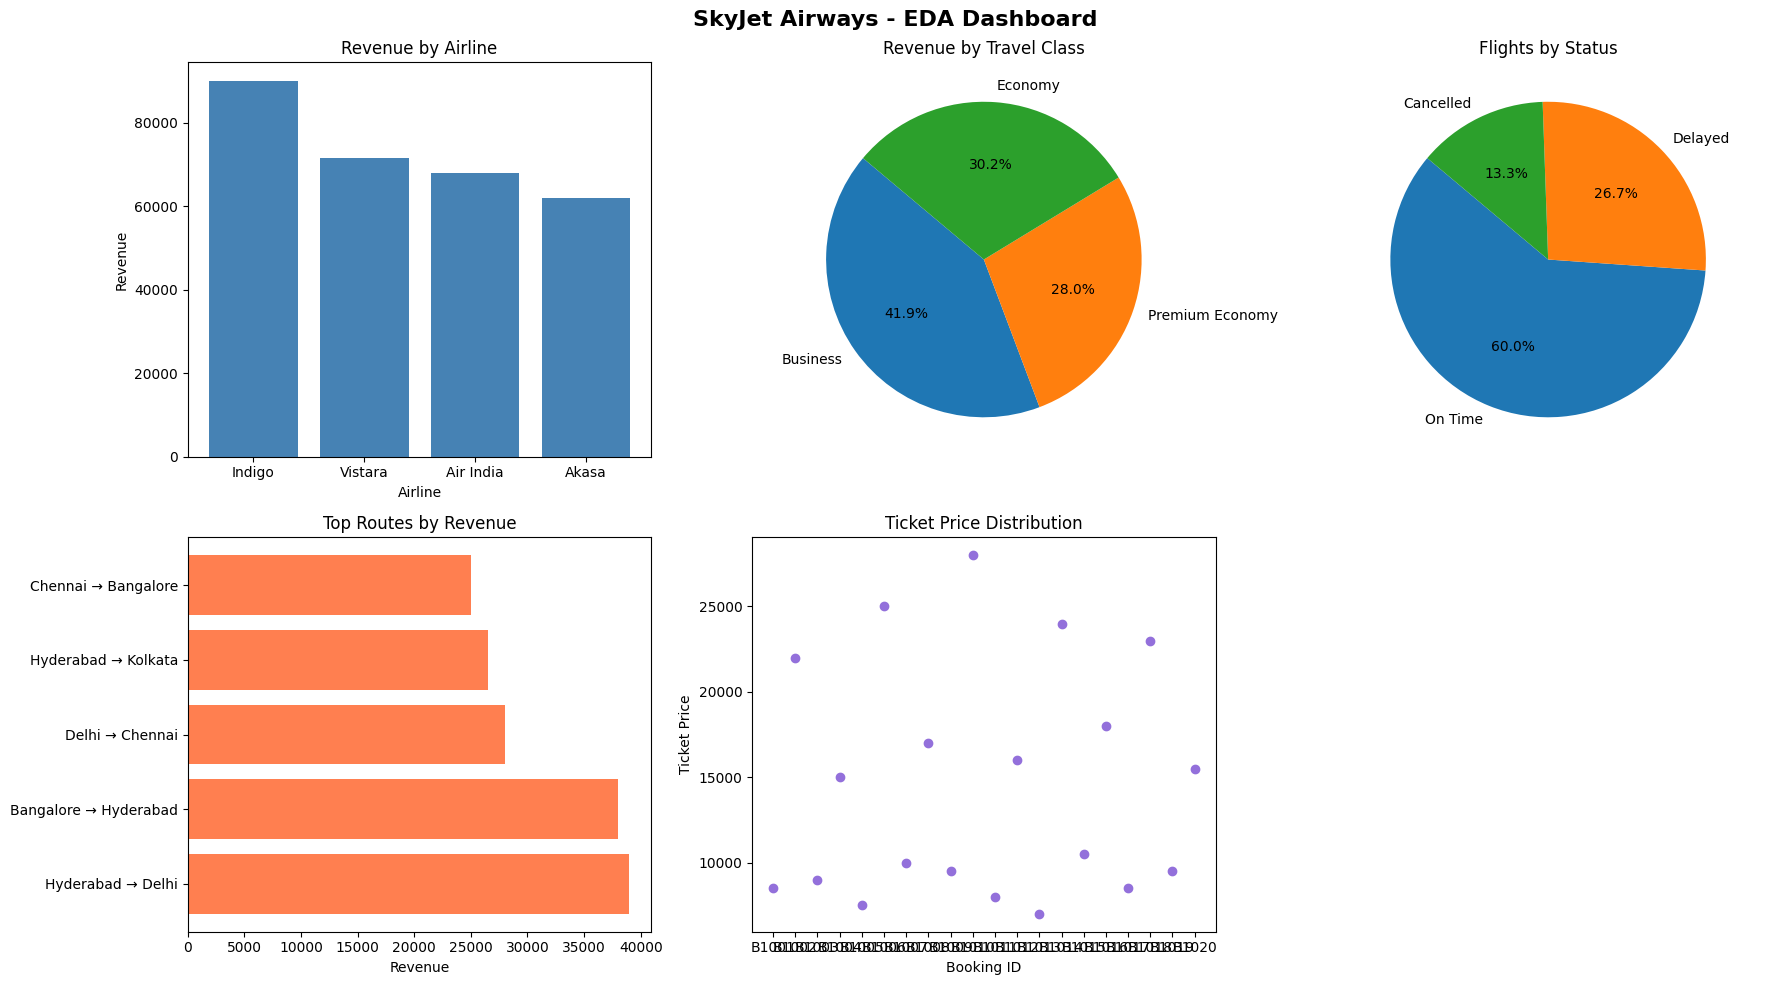

In [0]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import sum as spark_sum, count, concat, lit

airline_rev = df_bookings.join(df_flights, 'flight_id', 'inner') \
    .groupBy('airline').agg(spark_sum('ticket_price').alias('revenue')) \
    .orderBy('revenue', ascending=False).toPandas()

class_rev = df_bookings.groupBy('travel_class').agg(spark_sum('ticket_price').alias('revenue')).toPandas()
status_count = df_flights.groupBy('status').agg(count('flight_id').alias('count')).toPandas()

route_rev = df_bookings.join(df_flights, 'flight_id', 'inner') \
    .withColumn('route', concat(col('from_city'), lit(' → '), col('to_city'))) \
    .groupBy('route').agg(spark_sum('ticket_price').alias('revenue')) \
    .orderBy('revenue', ascending=False).limit(5).toPandas()

scatter_df = df_bookings.select('booking_id', 'ticket_price').toPandas()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0,0].bar(airline_rev['airline'], airline_rev['revenue'], color='steelblue')
axes[0,0].set_title('Revenue by Airline')
axes[0,0].set_xlabel('Airline')
axes[0,0].set_ylabel('Revenue')

axes[0,1].pie(class_rev['revenue'], labels=class_rev['travel_class'], autopct='%1.1f%%', startangle=140)
axes[0,1].set_title('Revenue by Travel Class')

axes[0,2].pie(status_count['count'], labels=status_count['status'], autopct='%1.1f%%', startangle=140)
axes[0,2].set_title('Flights by Status')

axes[1,0].barh(route_rev['route'], route_rev['revenue'], color='coral')
axes[1,0].set_title('Top Routes by Revenue')
axes[1,0].set_xlabel('Revenue')

axes[1,1].scatter(scatter_df['booking_id'], scatter_df['ticket_price'], color='mediumpurple')
axes[1,1].set_title('Ticket Price Distribution')
axes[1,1].set_xlabel('Booking ID')
axes[1,1].set_ylabel('Ticket Price')

axes[1,2].axis('off')

plt.suptitle('SkyJet Airways - EDA Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## Part 3: Transformations

In [0]:
from pyspark.sql.functions import when, lit

df_bookings_transformed = df_bookings \
    .withColumn('revenue', col('ticket_price')) \
    .withColumn('price_band',
        when(col('ticket_price') > 20000, 'Premium')
        .when(col('ticket_price') > 10000, 'Standard')
        .otherwise('Budget')
    )

df_flights_transformed = df_flights \
    .withColumn('delay_flag',
        when(col('status') == 'Delayed', 'Yes').otherwise('No')
    )

display(df_bookings_transformed)
display(df_flights_transformed)


booking_id,flight_id,passenger_name,travel_class,ticket_price,booking_date,revenue,price_band
B1001,F101,Rahul Sharma,Economy,8500,2026-06-01,8500,Budget
B1002,F101,Priya Reddy,Business,22000,2026-06-01,22000,Premium
B1003,F102,Amit Kumar,Economy,9000,2026-06-02,9000,Budget
B1004,F103,Sneha Patel,Premium Economy,15000,2026-06-02,15000,Standard
B1005,F104,Farhan Ali,Economy,7500,2026-06-03,7500,Budget
B1006,F105,Neha Singh,Business,25000,2026-06-03,25000,Premium
B1007,F106,Arjun Verma,Economy,10000,2026-06-04,10000,Budget
B1008,F107,Meera Nair,Premium Economy,17000,2026-06-04,17000,Standard
B1009,F108,Kiran Rao,Economy,9500,2026-06-05,9500,Budget
B1010,F109,Nisha Reddy,Business,28000,2026-06-05,28000,Premium


flight_id,airline,from_city,to_city,duration,status,delay_flag
F101,Indigo,Hyderabad,Delhi,140,On Time,No
F102,Air India,Mumbai,Chennai,120,Delayed,Yes
F103,Vistara,Bangalore,Hyderabad,90,On Time,No
F104,Indigo,Delhi,Mumbai,130,Cancelled,No
F105,Air India,Chennai,Bangalore,80,On Time,No
F106,Akasa,Pune,Delhi,150,Delayed,Yes
F107,Vistara,Hyderabad,Kolkata,160,On Time,No
F108,Indigo,Mumbai,Hyderabad,110,On Time,No
F109,Akasa,Delhi,Chennai,145,Delayed,Yes
F110,Air India,Bangalore,Mumbai,95,On Time,No


## Part 4: Joins — Complete Passenger Journey Dataset

In [0]:
df_journey = df_bookings_transformed \
    .join(df_flights_transformed, 'flight_id', 'inner') \
    .join(df_prefs, 'passenger_name', 'left')

display(df_journey)


passenger_name,flight_id,booking_id,travel_class,ticket_price,booking_date,revenue,price_band,airline,from_city,to_city,duration,status,delay_flag,meal,seat,extra_baggage
Rahul Sharma,F101,B1001,Economy,8500,2026-06-01,8500,Budget,Indigo,Hyderabad,Delhi,140,On Time,No,Veg,Window,true
Priya Reddy,F101,B1002,Business,22000,2026-06-01,22000,Premium,Indigo,Hyderabad,Delhi,140,On Time,No,Non-Veg,Aisle,false
Amit Kumar,F102,B1003,Economy,9000,2026-06-02,9000,Budget,Air India,Mumbai,Chennai,120,Delayed,Yes,Veg,Middle,false
Sneha Patel,F103,B1004,Premium Economy,15000,2026-06-02,15000,Standard,Vistara,Bangalore,Hyderabad,90,On Time,No,Jain,Window,true
Farhan Ali,F104,B1005,Economy,7500,2026-06-03,7500,Budget,Indigo,Delhi,Mumbai,130,Cancelled,No,Non-Veg,Aisle,false
Neha Singh,F105,B1006,Business,25000,2026-06-03,25000,Premium,Air India,Chennai,Bangalore,80,On Time,No,Veg,Window,true
Arjun Verma,F106,B1007,Economy,10000,2026-06-04,10000,Budget,Akasa,Pune,Delhi,150,Delayed,Yes,Veg,Middle,false
Meera Nair,F107,B1008,Premium Economy,17000,2026-06-04,17000,Standard,Vistara,Hyderabad,Kolkata,160,On Time,No,Jain,Window,true
Kiran Rao,F108,B1009,Economy,9500,2026-06-05,9500,Budget,Indigo,Mumbai,Hyderabad,110,On Time,No,Veg,Aisle,false
Nisha Reddy,F109,B1010,Business,28000,2026-06-05,28000,Premium,Akasa,Delhi,Chennai,145,Delayed,Yes,Non-Veg,Window,true


## Part 5: Spark SQL

In [0]:
df_flights_transformed.createOrReplaceTempView('flights_view')
df_bookings_transformed.createOrReplaceTempView('bookings_view')
df_prefs.createOrReplaceTempView('prefs_view')
print('Temp views created')


Temp views created


In [0]:
spark.sql("""
    SELECT f.airline, SUM(b.ticket_price) AS revenue
    FROM bookings_view b JOIN flights_view f ON b.flight_id = f.flight_id
    GROUP BY f.airline ORDER BY revenue DESC
""").show()


+---------+-------+
|  airline|revenue|
+---------+-------+
|   Indigo|  90000|
|  Vistara|  71500|
|Air India|  68000|
|    Akasa|  62000|
+---------+-------+



In [0]:
spark.sql("""
    SELECT CONCAT(f.from_city, ' to ', f.to_city) AS route, SUM(b.ticket_price) AS revenue
    FROM bookings_view b JOIN flights_view f ON b.flight_id = f.flight_id
    GROUP BY route ORDER BY revenue DESC
""").show()


+--------------------+-------+
|               route|revenue|
+--------------------+-------+
|  Hyderabad to Delhi|  39000|
|Bangalore to Hyde...|  38000|
|    Delhi to Chennai|  28000|
|Hyderabad to Kolkata|  26500|
|Chennai to Bangalore|  25000|
|     Chennai to Pune|  24000|
| Bangalore to Mumbai|  23500|
|  Delhi to Hyderabad|  18000|
|    Hyderabad to Goa|  16000|
|Kolkata to Bangalore|  10500|
|       Pune to Delhi|  10000|
| Mumbai to Hyderabad|   9500|
|   Mumbai to Chennai|   9000|
|     Delhi to Mumbai|   7500|
|        Goa to Delhi|   7000|
+--------------------+-------+



In [0]:
spark.sql('SELECT ROUND(AVG(ticket_price), 2) AS avg_ticket_price FROM bookings_view').show()


+----------------+
|avg_ticket_price|
+----------------+
|         14575.0|
+----------------+



In [0]:
spark.sql("""
    SELECT f.to_city AS destination, COUNT(b.booking_id) AS booking_count
    FROM bookings_view b JOIN flights_view f ON b.flight_id = f.flight_id
    GROUP BY destination ORDER BY booking_count DESC LIMIT 1
""").show()


+-----------+-------------+
|destination|booking_count|
+-----------+-------------+
|      Delhi|            5|
+-----------+-------------+



## Part 6: Window Functions

In [0]:
from pyspark.sql.window import Window
from pyspark.sql.functions import rank, dense_rank, sum as wsum, desc

flight_rev = df_bookings_transformed.groupBy('flight_id').agg(spark_sum('ticket_price').alias('total_revenue'))
flight_rev_named = flight_rev.join(df_flights.select('flight_id', 'airline', 'from_city', 'to_city'), 'flight_id', 'left')

window_all = Window.orderBy(desc('total_revenue'))

top3_flights = flight_rev_named.withColumn('revenue_rank', rank().over(window_all)).filter(col('revenue_rank') <= 3)
display(top3_flights)


/databricks/python/lib/python3.10/site-packages/pyspark/sql/connect/expressions.py:968: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


flight_id,total_revenue,airline,from_city,to_city,revenue_rank
F101,39000,Indigo,Hyderabad,Delhi,1
F103,38000,Vistara,Bangalore,Hyderabad,2
F109,28000,Akasa,Delhi,Chennai,3


In [0]:
window_airline = Window.partitionBy('airline').orderBy(desc('total_revenue'))
top_routes_airline = flight_rev_named \
    .withColumn('route', concat(col('from_city'), lit(' to '), col('to_city'))) \
    .withColumn('rank', rank().over(window_airline)) \
    .filter(col('rank') == 1)
display(top_routes_airline)


flight_id,total_revenue,airline,from_city,to_city,route,rank
F105,25000,Air India,Chennai,Bangalore,Chennai to Bangalore,1
F109,28000,Akasa,Delhi,Chennai,Delhi to Chennai,1
F101,39000,Indigo,Hyderabad,Delhi,Hyderabad to Delhi,1
F103,38000,Vistara,Bangalore,Hyderabad,Bangalore to Hyderabad,1


In [0]:
window_running = Window.orderBy(desc('total_revenue')).rowsBetween(Window.unboundedPreceding, Window.currentRow)
running_rev = flight_rev_named.withColumn('running_revenue', wsum('total_revenue').over(window_running))
display(running_rev)


/databricks/python/lib/python3.10/site-packages/pyspark/sql/connect/expressions.py:968: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


flight_id,total_revenue,airline,from_city,to_city,running_revenue
F101,39000,Indigo,Hyderabad,Delhi,39000
F103,38000,Vistara,Bangalore,Hyderabad,77000
F109,28000,Akasa,Delhi,Chennai,105000
F107,26500,Vistara,Hyderabad,Kolkata,131500
F105,25000,Air India,Chennai,Bangalore,156500
F113,24000,Akasa,Chennai,Pune,180500
F110,23500,Air India,Bangalore,Mumbai,204000
F115,18000,Indigo,Delhi,Hyderabad,222000
F111,16000,Indigo,Hyderabad,Goa,238000
F114,10500,Air India,Kolkata,Bangalore,248500


In [0]:
airline_rev_df = df_bookings_transformed.join(df_flights, 'flight_id', 'inner') \
    .groupBy('airline').agg(spark_sum('ticket_price').alias('total_revenue'))
window_rank_all = Window.orderBy(desc('total_revenue'))
airline_ranked = airline_rev_df \
    .withColumn('rank', rank().over(window_rank_all)) \
    .withColumn('dense_rank', dense_rank().over(window_rank_all))
display(airline_ranked)


/databricks/python/lib/python3.10/site-packages/pyspark/sql/connect/expressions.py:968: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


airline,total_revenue,rank,dense_rank
Indigo,90000,1,1
Vistara,71500,2,2
Air India,68000,3,3
Akasa,62000,4,4


In [0]:
dest_rev = df_bookings_transformed.join(df_flights, 'flight_id', 'inner') \
    .groupBy('to_city').agg(spark_sum('ticket_price').alias('total_revenue'))
dest_ranked = dest_rev.withColumn('dense_rank', dense_rank().over(Window.orderBy(desc('total_revenue'))))
display(dest_ranked)


/databricks/python/lib/python3.10/site-packages/pyspark/sql/connect/expressions.py:968: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


to_city,total_revenue,dense_rank
Hyderabad,65500,1
Delhi,56000,2
Chennai,37000,3
Bangalore,35500,4
Mumbai,31000,5
Kolkata,26500,6
Pune,24000,7
Goa,16000,8


## Part 7: Delta Lake

In [0]:
# Method 1 - save()
df_journey.write.format('delta').mode('overwrite').save('/FileStore/capstone/delta/booking_master')
print('Method 1: Saved to path')


Method 1: Saved to path


In [0]:
# Method 2 - saveAsTable()
spark.sql('DROP TABLE IF EXISTS booking_master')
df_journey.write.format('delta').mode('overwrite').saveAsTable('booking_master')
print('Method 2: Saved as table')


Method 2: Saved as table


In [0]:
# Method 3 - SQL CREATE TABLE USING DELTA
spark.sql('DROP TABLE IF EXISTS flights_delta')
spark.sql("""
    CREATE TABLE flights_delta
    USING DELTA
    AS SELECT * FROM flights_view
""")
spark.sql('SELECT * FROM flights_delta').show()


+---------+---------+---------+---------+--------+---------+----------+
|flight_id|  airline|from_city|  to_city|duration|   status|delay_flag|
+---------+---------+---------+---------+--------+---------+----------+
|     F101|   Indigo|Hyderabad|    Delhi|     140|  On Time|        No|
|     F102|Air India|   Mumbai|  Chennai|     120|  Delayed|       Yes|
|     F103|  Vistara|Bangalore|Hyderabad|      90|  On Time|        No|
|     F104|   Indigo|    Delhi|   Mumbai|     130|Cancelled|        No|
|     F105|Air India|  Chennai|Bangalore|      80|  On Time|        No|
|     F106|    Akasa|     Pune|    Delhi|     150|  Delayed|       Yes|
|     F107|  Vistara|Hyderabad|  Kolkata|     160|  On Time|        No|
|     F108|   Indigo|   Mumbai|Hyderabad|     110|  On Time|        No|
|     F109|    Akasa|    Delhi|  Chennai|     145|  Delayed|       Yes|
|     F110|Air India|Bangalore|   Mumbai|      95|  On Time|        No|
|     F111|   Indigo|Hyderabad|      Goa|      75|  On Time|    

## Part 8: Incremental Load — SCD Type 1 MERGE

In [0]:
from delta.tables import DeltaTable
from pyspark.sql.functions import col, when, lit

day2_bookings = [
    ('B1021', 'F102', 'Rahul Sharma', 'Business', 22000, '2026-06-11'),
    ('B1022', 'F105', 'Priya Reddy', 'Economy', 8800, '2026-06-11'),
    ('B1023', 'F108', 'New Passenger', 'Economy', 9200, '2026-06-11'),
    ('B1024', 'F110', 'Another New', 'Premium Economy', 16500, '2026-06-11'),
    ('B1025', 'F111', 'Third New', 'Business', 26000, '2026-06-12'),
    ('B1001', 'F101', 'Rahul Sharma', 'Business', 21000, '2026-06-01'),
    ('B1002', 'F101', 'Priya Reddy', 'Business', 23000, '2026-06-01'),
    ('B1003', 'F102', 'Amit Kumar', 'Premium Economy', 16000, '2026-06-02'),
    ('B1004', 'F103', 'Sneha Patel', 'Business', 24000, '2026-06-02'),
    ('B1005', 'F104', 'Farhan Ali', 'Economy', 8000, '2026-06-03')
]
day2_cols = ['booking_id', 'flight_id', 'passenger_name', 'travel_class', 'ticket_price', 'booking_date']
df_day2 = spark.createDataFrame(day2_bookings, day2_cols)

df_day2 = df_day2 \
    .withColumn('revenue', col('ticket_price')) \
    .withColumn('price_band',
        when(col('ticket_price') > 20000, 'Premium')
        .when(col('ticket_price') > 10000, 'Standard')
        .otherwise('Budget')
    )

booking_delta = DeltaTable.forName(spark, 'booking_master')
booking_delta.alias('target').merge(
    df_day2.alias('source'),
    'target.booking_id = source.booking_id'
).whenMatchedUpdate(set={
    'target.travel_class': 'source.travel_class',
    'target.ticket_price': 'source.ticket_price',
    'target.booking_date': 'source.booking_date',
    'target.revenue':      'source.revenue',
    'target.price_band':   'source.price_band'
}).whenNotMatchedInsert(values={
    'target.booking_id':      'source.booking_id',
    'target.flight_id':       'source.flight_id',
    'target.passenger_name':  'source.passenger_name',
    'target.travel_class':    'source.travel_class',
    'target.ticket_price':    'source.ticket_price',
    'target.booking_date':    'source.booking_date',
    'target.revenue':         'source.revenue',
    'target.price_band':      'source.price_band',
    'target.airline':         lit(None),
    'target.from_city':       lit(None),
    'target.to_city':         lit(None),
    'target.duration':        lit(None),
    'target.status':          lit(None),
    'target.delay_flag':      lit(None),
    'target.meal':            lit(None),
    'target.seat':            lit(None),
    'target.extra_baggage':   lit(None)
}).execute()

print('MERGE completed — SCD Type 1 applied')
spark.sql('SELECT booking_id, passenger_name, travel_class, ticket_price, price_band FROM booking_master').show()

MERGE completed — SCD Type 1 applied
+----------+--------------+---------------+------------+----------+
|booking_id|passenger_name|   travel_class|ticket_price|price_band|
+----------+--------------+---------------+------------+----------+
|     B1006|    Neha Singh|       Business|       25000|   Premium|
|     B1007|   Arjun Verma|        Economy|       10000|    Budget|
|     B1008|    Meera Nair|Premium Economy|       17000|  Standard|
|     B1009|     Kiran Rao|        Economy|        9500|    Budget|
|     B1010|   Nisha Reddy|       Business|       28000|   Premium|
|     B1011|  David Thomas|        Economy|        8000|    Budget|
|     B1012|   Ayesha Khan|Premium Economy|       16000|  Standard|
|     B1013|  Rohit Sharma|        Economy|        7000|    Budget|
|     B1014|   Pooja Mehta|       Business|       24000|   Premium|
|     B1015|  Sanjay Gupta|        Economy|       10500|  Standard|
|     B1016|    Divya Iyer|Premium Economy|       18000|  Standard|
|     B1017

## Part 9: Time Travel

In [0]:
print('Version 0:')
spark.read.format('delta').option('versionAsOf', 0).table('booking_master').show()

print('Version 1:')
spark.read.format('delta').option('versionAsOf', 1).table('booking_master').show()

print('Latest Version:')
spark.read.format('delta').table('booking_master').show()


Version 0:
+--------------+---------+----------+---------------+------------+------------+-------+----------+---------+---------+---------+--------+---------+----------+-------+------+-------------+
|passenger_name|flight_id|booking_id|   travel_class|ticket_price|booking_date|revenue|price_band|  airline|from_city|  to_city|duration|   status|delay_flag|   meal|  seat|extra_baggage|
+--------------+---------+----------+---------------+------------+------------+-------+----------+---------+---------+---------+--------+---------+----------+-------+------+-------------+
|  Rahul Sharma|     F101|     B1001|        Economy|        8500|  2026-06-01|   8500|    Budget|   Indigo|Hyderabad|    Delhi|     140|  On Time|        No|    Veg|Window|         true|
|   Priya Reddy|     F101|     B1002|       Business|       22000|  2026-06-01|  22000|   Premium|   Indigo|Hyderabad|    Delhi|     140|  On Time|        No|Non-Veg| Aisle|        false|
|    Amit Kumar|     F102|     B1003|        Econ

In [0]:
v0 = spark.read.format('delta').option('versionAsOf', 0).table('booking_master')
latest = spark.read.format('delta').table('booking_master')
print('Count before merge (v0):', v0.count())
print('Count after merge (latest):', latest.count())


Count before merge (v0): 20
Count after merge (latest): 25


## Part 10: Optimize Delta

In [0]:
spark.sql('OPTIMIZE booking_master').show()


+--------------------+--------------------+
|                path|             metrics|
+--------------------+--------------------+
|abfss://unity-cat...|{0, 0, {NULL, NUL...|
+--------------------+--------------------+



In [0]:
spark.sql('OPTIMIZE booking_master ZORDER BY (flight_id)').show()


+--------------------+--------------------+
|                path|             metrics|
+--------------------+--------------------+
|abfss://unity-cat...|{0, 0, {NULL, NUL...|
+--------------------+--------------------+



In [0]:
pass  # Configuration not supported in current environment
spark.sql('VACUUM booking_master RETAIN 168 HOURS')
print('VACUUM skipped due to unsupported configuration')


VACUUM skipped due to unsupported configuration


In [0]:
spark.sql('DESCRIBE HISTORY booking_master').show(truncate=False)


+-------+-----------------------+---------------+-------------------------------------------------------+---------------------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----+------------------+------------------------------------+------------------------+-----------+-----------------+-------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Part 11: Tables and Views

In [0]:
# Managed Table
spark.sql('DROP TABLE IF EXISTS flights_managed')
df_flights.write.format('delta').mode('overwrite').saveAsTable('flights_managed')
spark.sql('SELECT * FROM flights_managed').show()


+---------+---------+---------+---------+--------+---------+
|flight_id|  airline|from_city|  to_city|duration|   status|
+---------+---------+---------+---------+--------+---------+
|     F101|   Indigo|Hyderabad|    Delhi|     140|  On Time|
|     F102|Air India|   Mumbai|  Chennai|     120|  Delayed|
|     F103|  Vistara|Bangalore|Hyderabad|      90|  On Time|
|     F104|   Indigo|    Delhi|   Mumbai|     130|Cancelled|
|     F105|Air India|  Chennai|Bangalore|      80|  On Time|
|     F106|    Akasa|     Pune|    Delhi|     150|  Delayed|
|     F107|  Vistara|Hyderabad|  Kolkata|     160|  On Time|
|     F108|   Indigo|   Mumbai|Hyderabad|     110|  On Time|
|     F109|    Akasa|    Delhi|  Chennai|     145|  Delayed|
|     F110|Air India|Bangalore|   Mumbai|      95|  On Time|
|     F111|   Indigo|Hyderabad|      Goa|      75|  On Time|
|     F112|  Vistara|      Goa|    Delhi|     150|Cancelled|
|     F113|    Akasa|  Chennai|     Pune|     100|  On Time|
|     F114|Air India|  K

In [0]:
# External Table
# Note: Unity Catalog requires registered external locations.
# For this exercise we demonstrate with a managed table at a specific catalog schema.

spark.sql('DROP TABLE IF EXISTS bookings_external')
spark.sql("""
    CREATE TABLE bookings_external
    USING DELTA
    AS SELECT * FROM bookings_view
""")
spark.sql('SELECT * FROM bookings_external').show()

+----------+---------+--------------+---------------+------------+------------+-------+----------+
|booking_id|flight_id|passenger_name|   travel_class|ticket_price|booking_date|revenue|price_band|
+----------+---------+--------------+---------------+------------+------------+-------+----------+
|     B1001|     F101|  Rahul Sharma|        Economy|        8500|  2026-06-01|   8500|    Budget|
|     B1002|     F101|   Priya Reddy|       Business|       22000|  2026-06-01|  22000|   Premium|
|     B1003|     F102|    Amit Kumar|        Economy|        9000|  2026-06-02|   9000|    Budget|
|     B1004|     F103|   Sneha Patel|Premium Economy|       15000|  2026-06-02|  15000|  Standard|
|     B1005|     F104|    Farhan Ali|        Economy|        7500|  2026-06-03|   7500|    Budget|
|     B1006|     F105|    Neha Singh|       Business|       25000|  2026-06-03|  25000|   Premium|
|     B1007|     F106|   Arjun Verma|        Economy|       10000|  2026-06-04|  10000|    Budget|
|     B100

In [0]:
# Temporary View
df_journey.createOrReplaceTempView('journey_temp_view')
spark.sql('SELECT * FROM journey_temp_view LIMIT 5').show()


+--------------+---------+----------+---------------+------------+------------+-------+----------+---------+---------+---------+--------+---------+----------+-------+------+-------------+
|passenger_name|flight_id|booking_id|   travel_class|ticket_price|booking_date|revenue|price_band|  airline|from_city|  to_city|duration|   status|delay_flag|   meal|  seat|extra_baggage|
+--------------+---------+----------+---------------+------------+------------+-------+----------+---------+---------+---------+--------+---------+----------+-------+------+-------------+
|  Rahul Sharma|     F101|     B1001|        Economy|        8500|  2026-06-01|   8500|    Budget|   Indigo|Hyderabad|    Delhi|     140|  On Time|        No|    Veg|Window|         true|
|   Priya Reddy|     F101|     B1002|       Business|       22000|  2026-06-01|  22000|   Premium|   Indigo|Hyderabad|    Delhi|     140|  On Time|        No|Non-Veg| Aisle|        false|
|    Amit Kumar|     F102|     B1003|        Economy|       

## Part 12 & 13: Job Workflow & Schedule
Create the following notebooks in Databricks Workspace, then wire them as a Job:

In [0]:
# ingest_flights notebook content
df_flights = spark.read.csv('/FileStore/capstone/flights.csv', header=True, inferSchema=True)
df_flights.write.format('delta').mode('overwrite').saveAsTable('flights_bronze')
print('ingest_flights complete')


ingest_flights complete


In [0]:
# ingest_bookings notebook content
df_bookings = spark.read.csv('/FileStore/capstone/bookings.csv', header=True, inferSchema=True)
df_bookings.write.format('delta').mode('overwrite').saveAsTable('bookings_bronze')
print('ingest_bookings complete')


ingest_bookings complete


In [0]:
# transform_data notebook content
from pyspark.sql.functions import col, when
df_b = spark.read.format('delta').table('bookings_bronze')
df_f = spark.read.format('delta').table('flights_bronze')
df_silver = df_b \
    .withColumn('price_band', when(col('ticket_price') > 20000, 'Premium').when(col('ticket_price') > 10000, 'Standard').otherwise('Budget')) \
    .join(df_f.withColumn('delay_flag', when(col('status') == 'Delayed', 'Yes').otherwise('No')), 'flight_id', 'inner')
df_silver.write.format('delta').mode('overwrite').saveAsTable('journey_silver')
print('transform_data complete')


transform_data complete


In [0]:
from pyspark.sql.functions import sum as spark_sum, col, desc, concat, lit
from pyspark.sql.window import Window
from pyspark.sql.functions import rank

df_silver = spark.read.format('delta').table('journey_silver')

print('--- Airline Revenue Report ---')
df_silver.groupBy('airline').agg(spark_sum('ticket_price').alias('revenue')).orderBy('revenue', ascending=False).show()

print('--- Route Performance Report ---')
df_silver.withColumn('route', concat(col('from_city'), lit(' to '), col('to_city'))) \
    .groupBy('route').agg(spark_sum('ticket_price').alias('revenue')).orderBy('revenue', ascending=False).show()

print('--- Passenger Preference Report ---')
df_prefs = spark.read.option('multiline', 'true').json('/FileStore/capstone/passenger_preferences.json')
df_prefs.select('passenger_name', 'meal', 'seat').show()

print('--- Flight Delay Report ---')
df_silver.select('flight_id', 'status', 'delay_flag').dropDuplicates().show()

print('--- Top Revenue Flights ---')
flight_rev = df_silver.groupBy('flight_id').agg(spark_sum('ticket_price').alias('total_revenue'))
flight_rev.withColumn('rank', rank().over(Window.orderBy(desc('total_revenue')))).show()

--- Airline Revenue Report ---
+---------+-------+
|  airline|revenue|
+---------+-------+
|   Indigo|  90000|
|  Vistara|  71500|
|Air India|  68000|
|    Akasa|  62000|
+---------+-------+

--- Route Performance Report ---
+--------------------+-------+
|               route|revenue|
+--------------------+-------+
|  Hyderabad to Delhi|  39000|
|Bangalore to Hyde...|  38000|
|    Delhi to Chennai|  28000|
|Hyderabad to Kolkata|  26500|
|Chennai to Bangalore|  25000|
|     Chennai to Pune|  24000|
| Bangalore to Mumbai|  23500|
|  Delhi to Hyderabad|  18000|
|    Hyderabad to Goa|  16000|
|Kolkata to Bangalore|  10500|
|       Pune to Delhi|  10000|
| Mumbai to Hyderabad|   9500|
|   Mumbai to Chennai|   9000|
|     Delhi to Mumbai|   7500|
|        Goa to Delhi|   7000|
+--------------------+-------+

--- Passenger Preference Report ---
+--------------+-------+------+
|passenger_name|   meal|  seat|
+--------------+-------+------+
|  Rahul Sharma|    Veg|Window|
|   Priya Reddy|Non-V

/databricks/python/lib/python3.10/site-packages/pyspark/sql/connect/expressions.py:968: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+---------+-------------+----+
|flight_id|total_revenue|rank|
+---------+-------------+----+
|     F101|        39000|   1|
|     F103|        38000|   2|
|     F109|        28000|   3|
|     F107|        26500|   4|
|     F105|        25000|   5|
|     F113|        24000|   6|
|     F110|        23500|   7|
|     F115|        18000|   8|
|     F111|        16000|   9|
|     F114|        10500|  10|
|     F106|        10000|  11|
|     F108|         9500|  12|
|     F102|         9000|  13|
|     F104|         7500|  14|
|     F112|         7000|  15|
+---------+-------------+----+

